### Part A

In [42]:
# HERE YOU WILL WRITE CODE TO TEST A NUMBER OF PREDICTORS
# AND FINALLY CHOOSE AND TRAIN THE PREDICTOR THAT YOU WILL BE USING FOR PART B

# Importing Required Packages

In [43]:
#Import packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier 
from sklearn.ensemble import RandomForestClassifier # Import Random Forest Classifier 
from sklearn.linear_model import LogisticRegression #Import Logistic Regression
from sklearn.naive_bayes import GaussianNB #Import Gaussian Naive Bayes model
from sklearn import svm #Import svm model

# Loading the dataset

In [44]:
train_data = pd.read_csv('CE802_P2_Data.csv')
train_data.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F13,F14,F15,F16,F17,F18,F19,F20,F21,Class
0,-0.123210,2577.32,2183.52,7747.32,2.16,9693.21,-2.2498,-1381.98,3033.55,53.796,...,6.7860,1,-3.9290,-0.8095,3.5800,-5.9384,-9.3420,1,NaN,True
1,-2.064600,1200.12,1654.74,6027.72,2.16,9391.26,-2.7420,-1336.20,2081.35,33.514,...,5.5240,0,-1.6609,-2.3020,3.8880,-6.5640,-6.3806,1,NaN,False
2,-0.083748,2769.35,2661.42,7798.66,2.16,9296.28,-3.2130,-1531.16,3397.15,39.430,...,10.0870,0,-2.5100,-2.8190,2.1606,-5.2340,-9.6780,0,NaN,False
3,-2.808300,3161.52,2199.12,8369.32,5.16,7990.71,-2.2703,-1397.03,3289.99,42.012,...,15.5400,1,-2.2555,-0.9770,8.2160,-5.8166,-6.1512,0,42.06,True
4,-0.445800,2707.42,2083.62,9054.72,5.16,8691.81,-3.7310,-804.04,1903.35,43.172,...,4.5188,0,-1.7843,-1.3690,0.7562,-6.4060,-9.5320,0,NaN,True


In [45]:
train_data.shape

(1000, 22)

In [46]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      1000 non-null   float64
 1   F2      1000 non-null   float64
 2   F3      1000 non-null   float64
 3   F4      1000 non-null   float64
 4   F5      1000 non-null   float64
 5   F6      1000 non-null   float64
 6   F7      1000 non-null   float64
 7   F8      1000 non-null   float64
 8   F9      1000 non-null   float64
 9   F10     1000 non-null   float64
 10  F11     1000 non-null   float64
 11  F12     1000 non-null   float64
 12  F13     1000 non-null   float64
 13  F14     1000 non-null   int64  
 14  F15     1000 non-null   float64
 15  F16     1000 non-null   float64
 16  F17     1000 non-null   float64
 17  F18     1000 non-null   float64
 18  F19     1000 non-null   float64
 19  F20     1000 non-null   int64  
 20  F21     500 non-null    float64
 21  Class   1000 non-null   bool   
dtypes

In [47]:
train_data.describe(include='all')

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F13,F14,F15,F16,F17,F18,F19,F20,F21,Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,500.000000,1000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,506
mean,-1.512791,2520.923949,2120.448916,8459.648266,3.747000,8571.085469,-2.344597,-1249.307215,3205.505415,36.836583,...,14.382299,0.481000,-2.315266,-1.338608,2.321917,-6.220027,-7.528717,0.507000,35.050560,NaN
std,2.015813,747.470842,1587.054314,2074.355688,1.498224,2108.672583,0.614178,493.077434,511.582397,9.723283,...,10.285697,0.499889,0.899919,0.901204,1.805553,1.706913,1.739357,0.500201,3.188244,NaN
min,-17.514000,-2459.880000,-7321.080000,-655.080000,2.160000,-5873.790000,-5.111000,-4531.040000,-718.650000,5.420000,...,4.232328,0.000000,-5.742000,-4.955000,0.344240,-13.326000,-14.710000,0.000000,24.930000,NaN
25%,-1.978575,2440.070000,1505.370000,7659.360000,2.160000,8291.085000,-2.724500,-1423.122500,3071.450000,30.700500,...,7.422000,0.000000,-2.798250,-1.707000,0.934900,-6.950000,-8.299000,0.000000,32.850000,NaN
50%,-0.760800,2709.570000,1762.455000,8046.520000,5.160000,8986.140000,-2.210750,-1356.980000,3216.461500,36.759900,...,11.312000,0.000000,-2.024800,-1.057250,1.764500,-5.677500,-7.018100,1.000000,34.905000,NaN
75%,-0.191055,2836.273250,2227.920000,8686.670000,5.160000,9414.442500,-1.857700,-1222.365000,3341.050000,42.986500,...,17.182500,1.000000,-1.613575,-0.661825,3.147000,-4.958000,-6.226650,1.000000,37.275000,NaN


# Exploratory Data Analysis

## Converting boolean values to Numerical values 

In [48]:
train_data.dtypes

F1       float64
F2       float64
F3       float64
F4       float64
F5       float64
F6       float64
F7       float64
F8       float64
F9       float64
F10      float64
F11      float64
F12      float64
F13      float64
F14        int64
F15      float64
F16      float64
F17      float64
F18      float64
F19      float64
F20        int64
F21      float64
Class       bool
dtype: object

In [49]:
def converter(x):
    if x == True:
        return 1
    else:
        return 0

train_data['Class'] = train_data['Class'].apply(converter)

In [50]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      1000 non-null   float64
 1   F2      1000 non-null   float64
 2   F3      1000 non-null   float64
 3   F4      1000 non-null   float64
 4   F5      1000 non-null   float64
 5   F6      1000 non-null   float64
 6   F7      1000 non-null   float64
 7   F8      1000 non-null   float64
 8   F9      1000 non-null   float64
 9   F10     1000 non-null   float64
 10  F11     1000 non-null   float64
 11  F12     1000 non-null   float64
 12  F13     1000 non-null   float64
 13  F14     1000 non-null   int64  
 14  F15     1000 non-null   float64
 15  F16     1000 non-null   float64
 16  F17     1000 non-null   float64
 17  F18     1000 non-null   float64
 18  F19     1000 non-null   float64
 19  F20     1000 non-null   int64  
 20  F21     500 non-null    float64
 21  Class   1000 non-null   int64  
dtypes

## Dealing with Null values in the dataset 

In [51]:
train_data.isnull().sum()

F1         0
F2         0
F3         0
F4         0
F5         0
F6         0
F7         0
F8         0
F9         0
F10        0
F11        0
F12        0
F13        0
F14        0
F15        0
F16        0
F17        0
F18        0
F19        0
F20        0
F21      500
Class      0
dtype: int64

In [52]:
#Mean Imputation for Null values in dataset
for i in train_data.columns:
     train_data[i].fillna(train_data[i].mean(),inplace = True)


In [53]:
train_data.isnull().sum()

F1       0
F2       0
F3       0
F4       0
F5       0
F6       0
F7       0
F8       0
F9       0
F10      0
F11      0
F12      0
F13      0
F14      0
F15      0
F16      0
F17      0
F18      0
F19      0
F20      0
F21      0
Class    0
dtype: int64

## Dealing with Data Duplicates 

In [54]:
train_data.duplicated().sum()

0

## Handling Outliers 

In [55]:
train_data.boxplot()

<AxesSubplot:xlabel='Recall (Positive label: 1)', ylabel='Precision (Positive label: 1)'>

# Collinearity

In [56]:
train_data.corr()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F13,F14,F15,F16,F17,F18,F19,F20,F21,Class
F1,1.000000,0.062524,0.015558,-0.103306,0.026647,-0.009273,-0.014207,-0.009692,0.045471,-0.012373,...,0.005803,0.030887,-0.027272,-0.012591,-0.025697,0.057872,-0.041213,-0.049109,-0.041697,0.018146
F2,0.062524,1.000000,-0.122382,0.042754,0.000864,-0.123040,-0.004322,-0.029493,0.296979,0.044698,...,-0.001953,0.009380,-0.003282,-0.042462,-0.004553,0.006406,-0.287894,-0.009826,0.082669,0.018274
F3,0.015558,-0.122382,1.000000,-0.006837,0.031515,-0.000484,-0.061114,0.010592,-0.031391,0.021023,...,-0.003868,0.003917,-0.003992,0.005760,-0.028827,0.236772,-0.009438,-0.062860,0.050275,0.216721
F4,-0.103306,0.042754,-0.006837,1.000000,-0.033091,0.022679,0.003705,0.010158,-0.040083,-0.000878,...,0.005679,-0.025854,0.228368,0.055473,-0.011339,0.053769,0.014486,-0.022925,0.057922,0.258222
F5,0.026647,0.000864,0.031515,-0.033091,1.000000,-0.002549,-0.031534,0.003681,-0.006373,0.026336,...,0.014585,-0.025858,-0.002169,0.069944,-0.047893,-0.012559,-0.005132,0.019222,0.018806,0.041377
F6,-0.009273,-0.123040,-0.000484,0.022679,-0.002549,1.000000,-0.044764,-0.238497,0.044801,-0.019980,...,0.012361,-0.026289,0.004537,-0.213338,-0.007732,0.033943,0.018811,0.019158,0.055393,-0.000403
F7,-0.014207,-0.004322,-0.061114,0.003705,-0.031534,-0.044764,1.000000,-0.053084,0.008733,-0.037295,...,0.000686,0.004205,0.025508,0.006901,-0.005760,-0.068408,-0.064432,-0.007055,-0.027462,0.026389
F8,-0.009692,-0.029493,0.010592,0.010158,0.003681,-0.238497,-0.053084,1.000000,-0.254483,0.047412,...,-0.024747,0.024538,0.004320,-0.000167,-0.262439,-0.037088,0.008624,-0.070705,-0.029683,-0.012088
F9,0.045471,0.296979,-0.031391,-0.040083,-0.006373,0.044801,0.008733,-0.254483,1.000000,-0.021339,...,-0.020361,0.016723,-0.037528,-0.041041,-0.000216,0.063753,0.014832,-0.020466,0.013278,-0.009307
F10,-0.012373,0.044698,0.021023,-0.000878,0.026336,-0.019980,-0.037295,0.047412,-0.021339,1.000000,...,-0.023469,-0.067913,0.019820,0.023646,-0.020446,-0.006108,0.001644,-0.042880,0.046261,0.027641


In [57]:
plt.figure(figsize=(12,10))
sns.heatmap(train_data.corr(),annot=True, linewidths=0.5, fmt=".2f", cmap="YlGnBu")

<AxesSubplot:>

# Feature Selection

In [58]:
#split dataset in features and target variable
X = train_data.drop('Class', axis=1)
Y = train_data['Class']

#Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# Model Building

## Decision Tree Classifier

In [59]:
# Create Decision Tree classifer object
DTClassifier = DecisionTreeClassifier() 

# Train Decision Tree Classifer
DTClassifier = DTClassifier.fit(X_train, y_train)

#Predict the response for test dataset
y_DT_pred = DTClassifier.predict(X_test)

### Evaluation of the Model

In [60]:
# Model Accuracy.
print("Accuracy of the Decision Tree Model is :",metrics.accuracy_score(y_test, y_DT_pred)*100,"%")

#Calculating Precision and Recall
precision = precision_score(y_test, y_DT_pred)
recall = recall_score(y_test, y_DT_pred)
 
print('Precision of the Decision Tree Model is : ',precision*100,"%")
print('Recall of the Decision Tree Model is : ',recall*100 ,"%")
 
#Plotting Precision-Recall Curve
disp = plot_precision_recall_curve(DTClassifier, X_test, y_test)

Accuracy of the Decision Tree Model is : 84.5 %
Precision of the Decision Tree Model is :  88.3495145631068 %
Recall of the Decision Tree Model is :  82.72727272727273 %


C:\Users\heman\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


### Optimizing Decision Tree Performance 

In [61]:
# Create Optimized Decision Tree classifer object
O_DTClassifier = DecisionTreeClassifier(criterion="gini", max_depth=5, splitter="best")

# Train Decision Tree Classifer
O_DTClassifier = O_DTClassifier.fit(X_train,y_train)

#Predict the response for test dataset
y_ODTC_pred = O_DTClassifier.predict(X_test)

### Evaluation of the Optimized Decision Tree Model 

In [62]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy of the Optimized Decision Tree Model is :",metrics.accuracy_score(y_test, y_ODTC_pred)*100, "$")

#Calculating Precision and Recall
precision = precision_score(y_test, y_ODTC_pred)
recall = recall_score(y_test, y_ODTC_pred)
 
print('Precision of the Optimized Decision Tree Model is: ',precision*100, "%")
print('Recall of the Optimized Decision Tree Model is: ',recall*100, "%")
 
#Plotting Precision-Recall Curve
disp = plot_precision_recall_curve(O_DTClassifier, X_test, y_test)

Accuracy of the Optimized Decision Tree Model is : 88.5 $
Precision of the Optimized Decision Tree Model is:  87.17948717948718 %
Recall of the Optimized Decision Tree Model is:  92.72727272727272 %


C:\Users\heman\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


### Cross validation 

In [63]:
#Evaluating the performance of a Optimized Decision tree model through cross validation
cv_accuracy = cross_val_score(O_DTClassifier, X, Y, cv=5, scoring="accuracy")
print(cv_accuracy)

#Cross validation Accuracy
print(f"The cross-validated accuracy of the Optimized Decision Tree Model is: {np.mean(cv_accuracy)*100:.2f}%")

[0.895 0.845 0.83  0.875 0.89 ]
The cross-validated accuracy of the Optimized Decision Tree Model is: 86.70%


###  Visualization of Optimized Decision Tree Performance

In [64]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_ODTC_pred}).head()

,Actual,Predicted
993,0,0
859,1,1
298,0,0
553,1,0
672,0,1


C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


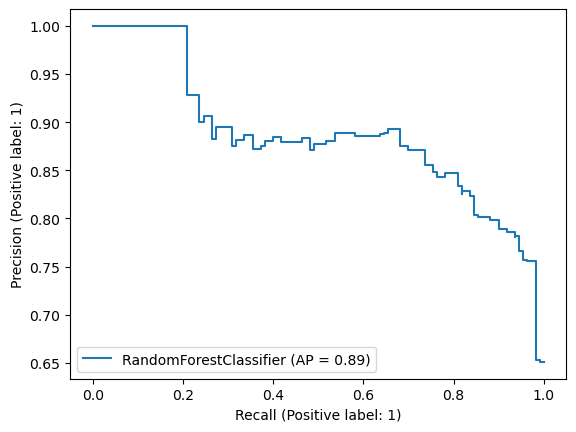

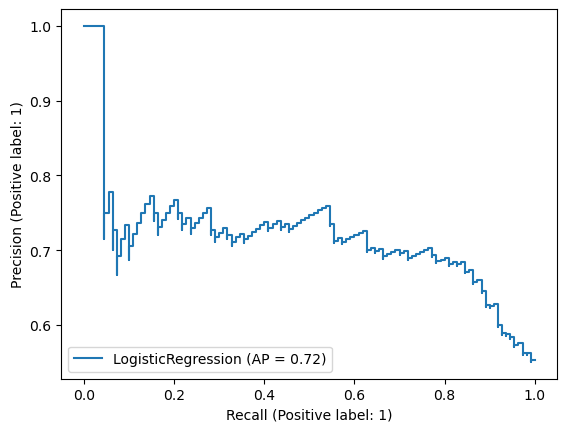

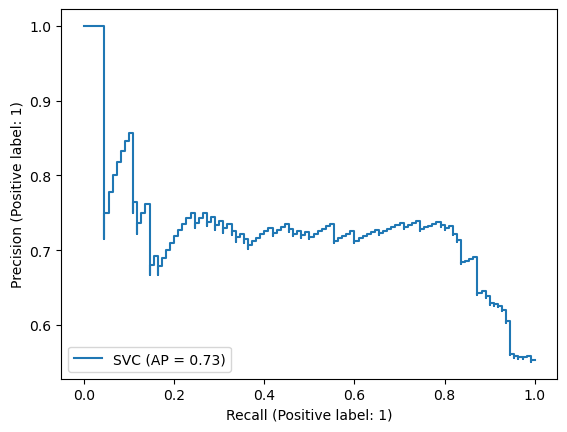

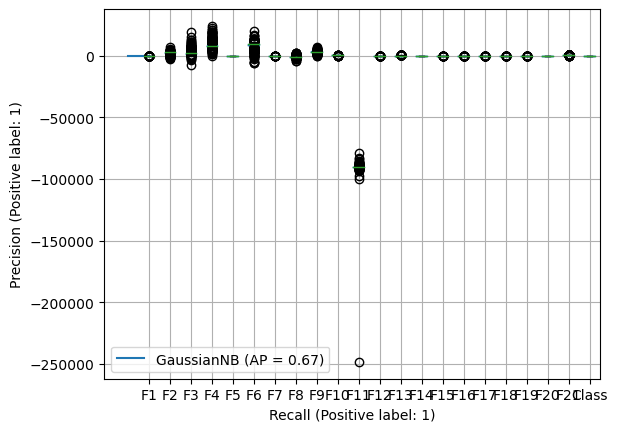

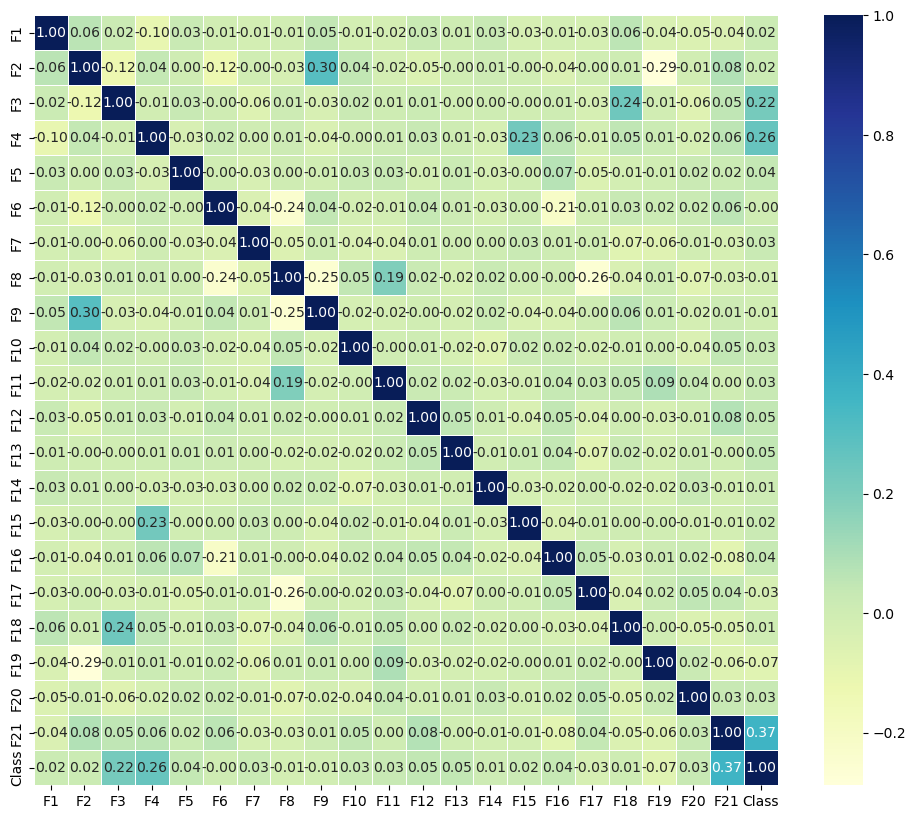

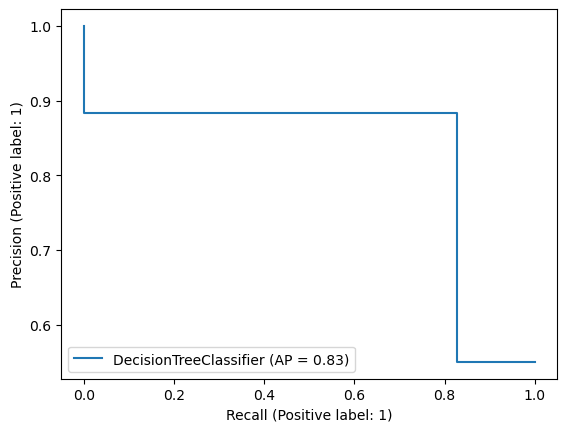

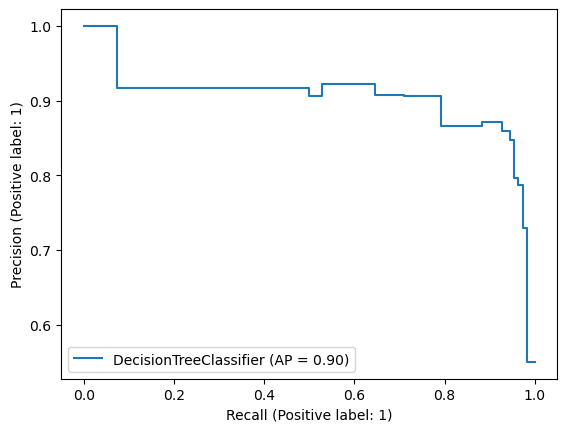

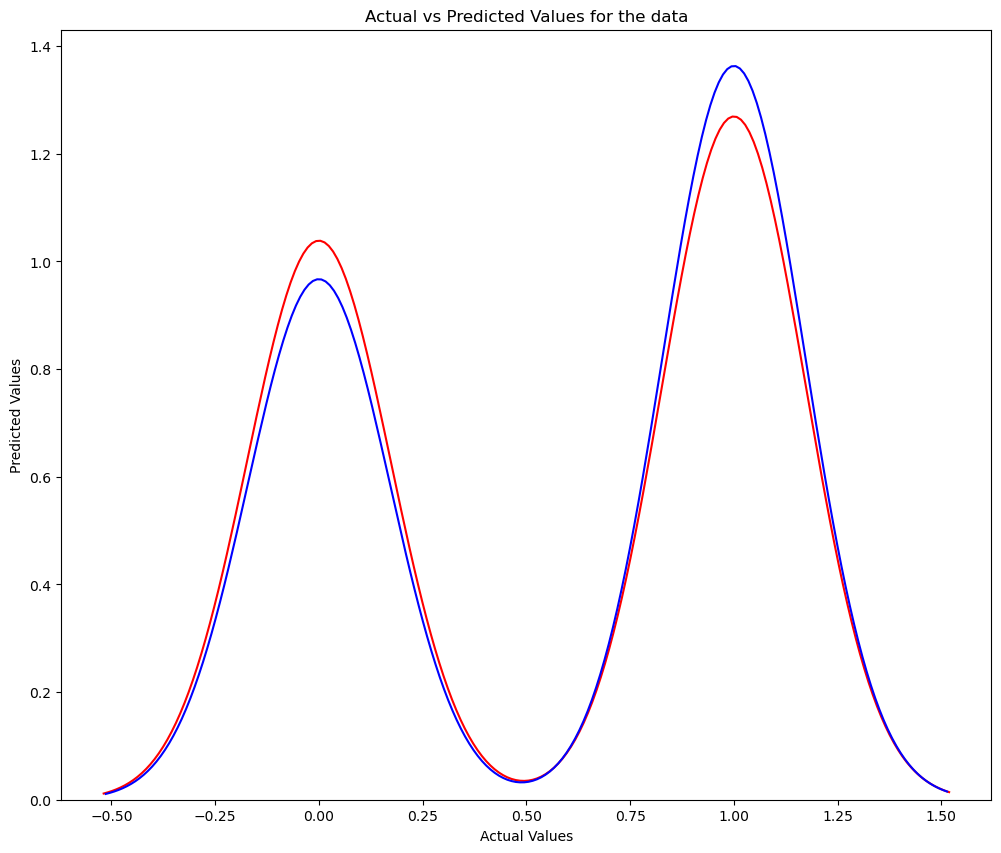

In [65]:
width = 12
height = 10
plt.figure(figsize=(width, height))


ax1 = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(y_ODTC_pred, hist=False, color="b", label="Predicted Values" , ax=ax1)


plt.title('Actual vs Predicted Values for the data')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.show()

## Random Forest Classifier 

In [66]:
# Create Random Forests classifier object
RFClassifier = RandomForestClassifier(n_estimators=100, random_state=0)

# Train Random Forests Classifer
RFClassifier = RFClassifier.fit(X_train, y_train)

#Predict the response for test dataset
y_RF_pred = RFClassifier.predict(X_test)

### Evaluation of the Model  

In [67]:
# Model Accuracy
print("Accuracy of the Random Forest Classifier is:",metrics.accuracy_score(y_test, y_RF_pred)*100, "%")

#Calculating Precision and Recall
precision = precision_score(y_test, y_RF_pred)
recall = recall_score(y_test, y_RF_pred)
 
print('Precision of the Random Forest Classifier: ',precision*100, "%")
print('Recall of the Random Forest Classifier: ',recall*100, "%")
 
#Plotting Precision-Recall Curve
disp = plot_precision_recall_curve(RFClassifier, X_test, y_test)

Accuracy of the Random Forest Classifier is: 80.5 %
Precision of the Random Forest Classifier:  85.14851485148515 %
Recall of the Random Forest Classifier:  78.18181818181819 %


C:\Users\heman\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


### Cross Validation 

In [68]:
#Cross validation
RF_cross_val = cross_val_score(RFClassifier, X, Y, cv=5, scoring="accuracy")
print(RF_cross_val)

#Cross validation Accuracy
print(f"The cross-validated accuracy is: {np.mean(RF_cross_val)*100:.2f}%")

[0.82  0.86  0.875 0.835 0.85 ]
The cross-validated accuracy is: 84.80%


### Optimizing Random forest Classifier Performance 

In [69]:
# Create Random Forests classifier Object
O_RFClassifier = RandomForestClassifier(criterion="entropy", max_depth=9, min_samples_leaf=2, min_samples_split=8)

# Train Random Forests Classifer
O_RFClassifier = O_RFClassifier.fit(X_train, y_train)

#Predict the response for dataset
y_ORF_pred = O_RFClassifier.predict(X_test)

In [70]:
# Accuracy of the Optimized Random Forest Classifier
print("Accuracy of the Optimized Random Forest Classifier is :",metrics.accuracy_score(y_test, y_ORF_pred)*100, "%")

Accuracy of the Optimized Random Forest Classifier is : 81.5 %


##  Logistic Regression

In [71]:
# Create a Logistic Regression Object
Logistic_regressor = LogisticRegression()

#Train Logistic Regression
Logistic_regressor = Logistic_regressor.fit(X_train, y_train)

#Predict the response
y_LR_pred = Logistic_regressor.predict(X_test)

C:\Users\heman\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Evaluation of model 

In [72]:
#Accuracy of the Logistic Regression Model
print("The Accuracy of the Logistic Regression model is: ", metrics.accuracy_score(y_test, y_LR_pred)*100, "%")

#Calculating Precision and Recall
precision = precision_score(y_test, y_LR_pred)
recall = recall_score(y_test, y_LR_pred)
 
print('Precision of the Logistic Regression Model is: ',precision*100, "%")
print('Recall of the Logistic Regression Model is: ',recall*100, "%")
 
#Plotting Precision-Recall Curve
disp = plot_precision_recall_curve(Logistic_regressor, X_test, y_test)

The Accuracy of the Logistic Regression model is:  66.5 %
Precision of the Logistic Regression Model is:  75.29411764705883 %
Recall of the Logistic Regression Model is:  58.18181818181818 %


C:\Users\heman\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


### Cross Validation 

In [73]:
#Cross validation
LR_cross_val = cross_val_score(Logistic_regressor, X, Y, cv=5, scoring="accuracy")
print(LR_cross_val)

#Cross validation Accuracy
print(f"The cross-validated accuracy is: {np.mean(LR_cross_val)*100:.2f}%")

[0.695 0.69  0.715 0.715 0.65 ]
The cross-validated accuracy is: 69.30%


C:\Users\heman\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\heman\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

## Support Vector Machine(SVM) 

In [74]:
#Create a svm Classifier
SVC = svm.SVC(kernel='linear', C=0.025) # Linear Kernel

#Train the model using the training sets
SVC = SVC.fit(X_train, y_train)

#Predict the response for test dataset
y_SVC_pred = SVC.predict(X_test)

### Evaluation of the Model 

In [75]:
# Model Accuracy
print("Accuracy of the SVM is :",metrics.accuracy_score(y_test, y_SVC_pred)*100,"%")

#Calculating Precision and Recall
precision = precision_score(y_test, y_SVC_pred)
recall = recall_score(y_test,y_SVC_pred)
 
print('Precision of the SVMl is: ',precision*100, "%")
print('Recall of the SVM is: ',recall*100, "%")
 
#Plotting Precision-Recall Curve
disp = plot_precision_recall_curve(SVC, X_test, y_test)

Accuracy of the SVM is : 66.5 %
Precision of the SVMl is:  70.47619047619048 %
Recall of the SVM is:  67.27272727272727 %


C:\Users\heman\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


### Cross Validation 

In [76]:
#Cross validation
SVC_cross_val = cross_val_score(SVC, X, Y, cv=5, scoring="accuracy")
print(SVC_cross_val)

#Cross validation Accuracy
print(f"The cross-validated accuracy is: {np.mean(SVC_cross_val)*100:.2f}%")

[0.705 0.73  0.73  0.745 0.69 ]
The cross-validated accuracy is: 72.00%


## Naive Bayes Classification 

In [77]:
#Create a Gaussian Classifier
NBC = GaussianNB()

#Train the model using the training sets
NBC.fit(X_train, y_train)

#Predict the response for test dataset
y_NBC_pred = NBC.predict(X_test)

### Evaluation of the Model 

In [78]:
# Model Accuracy
print("Accuracy of the Naive Bayes Model is :",metrics.accuracy_score(y_test, y_NBC_pred)*100, "%")

#Calculating Precision and Recall
precision = precision_score(y_test, y_NBC_pred)
recall = recall_score(y_test,y_NBC_pred)
 
print('Precision of the Logistic Regression Model is: ',precision*100, "%")
print('Recall of the Logistic Regression Model is: ',recall*100, "%")
 
#Plotting Precision-Recall Curve
disp = plot_precision_recall_curve(NBC, X_test, y_test)

Accuracy of the Naive Bayes Model is : 56.49999999999999 %
Precision of the Logistic Regression Model is:  56.21621621621622 %
Recall of the Logistic Regression Model is:  94.54545454545455 %


C:\Users\heman\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


### Cross Validation

In [79]:
#Cross validation
NBC_cross_val = cross_val_score(NBC, X, Y, cv=5, scoring="accuracy")
print(NBC_cross_val) 

#Cross validation Accuracy
print(f"The cross-validated accuracy is: {np.mean(NBC_cross_val)*100:.2f}%")

[0.555 0.495 0.615 0.545 0.535]
The cross-validated accuracy is: 54.90%


### Part B

In [81]:
# HERE YOU WILL USE THIS TEMPLATE TO SAVE THE PREDICTIONS ON THE TEST SET

# Load the test data
test_df = pd.read_csv('CE802_P2_Test.csv')

# Make sure you work on a copy
test_data = test_df.iloc[:,:-1].copy()

#Dealing with null values
for i in test_data.columns:
     test_data[i].fillna(test_data[i].mean(),inplace = True)

predicted = O_DTClassifier.predict(test_data) # CHANGE HERE -- use your previously trained predictor and apply it to test_data
                # (test_data can be modified if needed but make sure you don't change the order of the rows)...

# Replace the last (empty) column with your prediction
test_df.iloc[:,-1] = predicted

# Save to the destination file
test_df.to_csv('CE802_P2_Test_Predictions.csv', index=False, float_format='%.8g')

# IMPORTANT!! Make sure only the last column has changed
assert pd.read_csv('CE802_P2_Test.csv').iloc[:,:-1].equals(pd.read_csv('CE802_P2_Test_Predictions.csv').iloc[:,:-1])